Data Cleaning and Visualization Using R - 3/14/2026 - April Taylor

In [1]:
# Libraried required
library(readxl)
library(writexl)

#Read excel file
df = read_excel("C:/Files/Excel/DA_PythonR/AirBnBSummary_v2.xlsx")

In [2]:
#Remove duplicate rows for data integrity
df = unique(df)

#Normalize text fields by converting them to title case
df$host_name = tools::toTitleCase(df$host_name)
df$neighbourhood = tools::toTitleCase(df$neighbourhood)
df$room_type = tools::toTitleCase(df$room_type)

#Identify all numeric columns in dataset
num_cols = sapply(df, is.numeric)

#Replace missing numeric values with median of each column
for (col in names(df)[num_cols]) {
    med = median(df[[col]], na.rm = TRUE)
    df[[col]][is.na(df[[col]])] = med
}


In [3]:
#Calculate quartiles for the price variable
Q1 = quantile(df$price, 0.25)
Q3 = quantile(df$price, 0.75)
IQR = Q3 - Q1

#Define acceptable lower and upper bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

#Filter out rows with price values outside the bounds set
df_clean = df[df$price >= lower & df$price <= upper, ]

#Save the cleaned dataset to excel file
write_xlsx(df_clean, "Cleaned_Airbnb_v2.xlsx")

In [4]:
#Compute basic summary statistics from the now cleaned dataset
total_listings = nrow(df_clean)
min_price = min(df_clean$price)
max_price = max(df_clean$price)
mean_price = mean(df_clean$price)
median_reviews = median(df_clean$number_of_reviews)

#Calculate the mode of minimum_nights
mode_min_nights = as.numeric(names(sort(table(df_clean$minimum_nights), decreasing = TRUE) [1]))

#Additional metrics (price availability and correlation with availability
std_price = sd(df_clean$price)
correlation = cor(df_clean$price, df_clean$availability_365)

#Store all computed statistics in a named list
stats = list(
    Total_Listings = total_listings,
    Min_Price = min_price,
    Max_Price = max_price,
    Mean_Price = mean_price,
    Median_Reviews = median_reviews,
    Mode_Min_Nights = mode_min_nights,
    STD_Price = std_price,
    Correlation = correlation
)

#Display the results
stats

$Total_Listings
[1] 1657

$Min_Price
[1] 20

$Max_Price
[1] 308

$Mean_Price
[1] 124.1328

$Median_Reviews
[1] 20

$Mode_Min_Nights
[1] 1

$STD_Price
[1] 61.49677

$Correlation
[1] 0.1064181

[1] "id"                "host_id"           "host_name"        
 [4] "neighbourhood"     "room_type"         "price"            
 [7] "minimum_nights"    "number_of_reviews" "availability_365" 
[10] "<StudentID>"

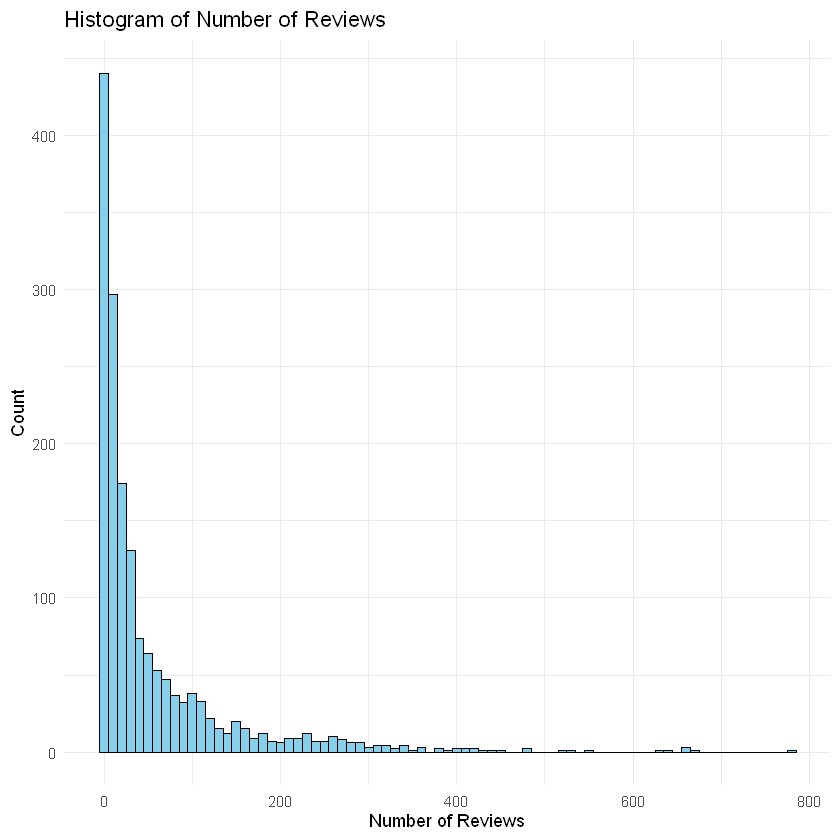

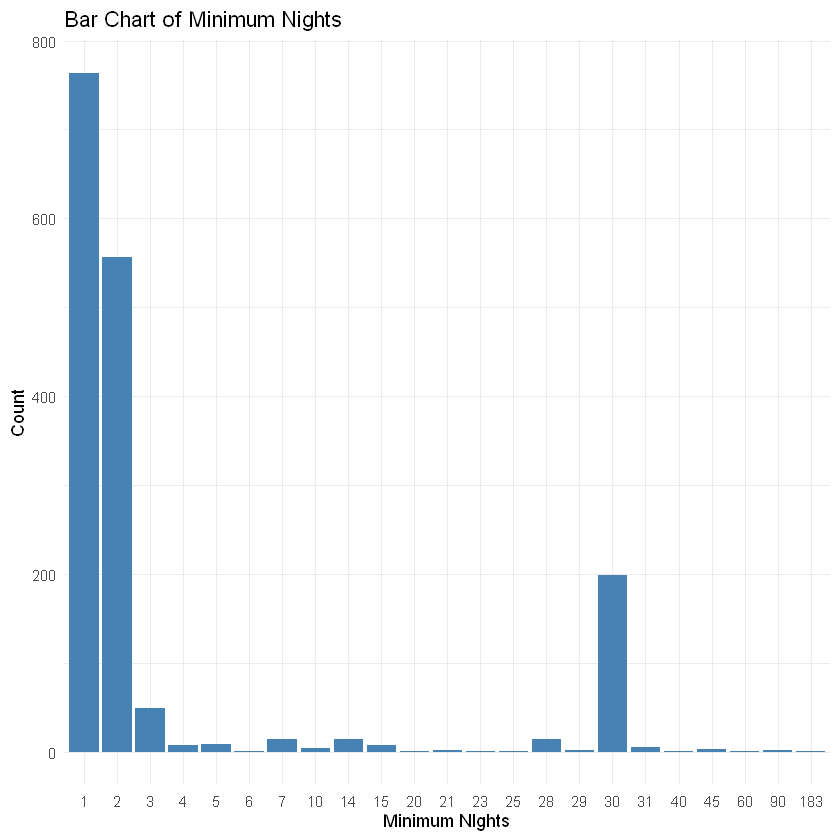

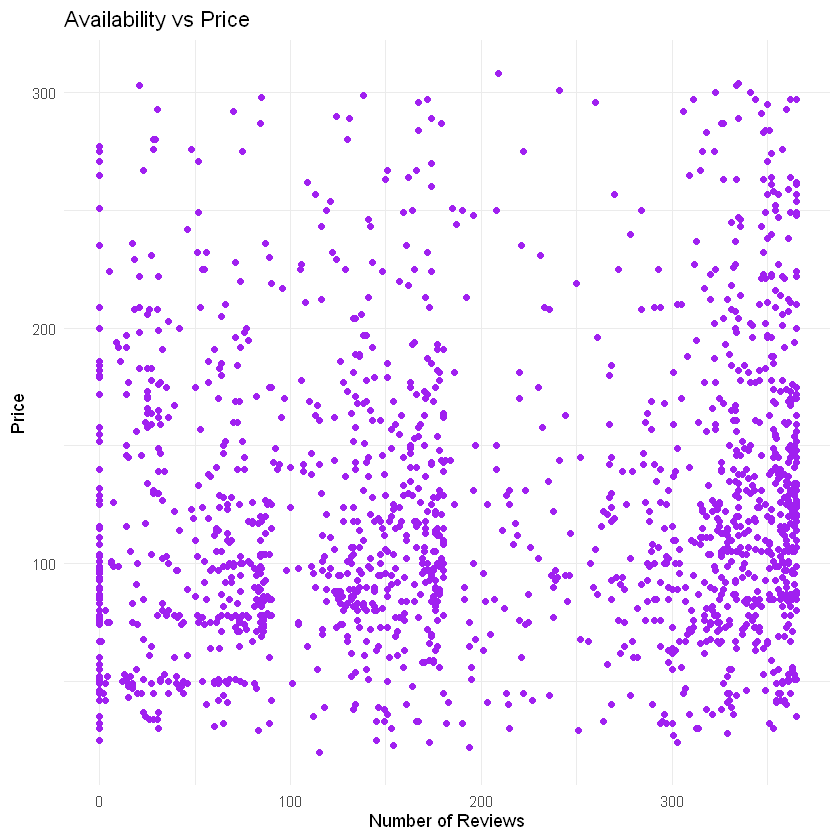

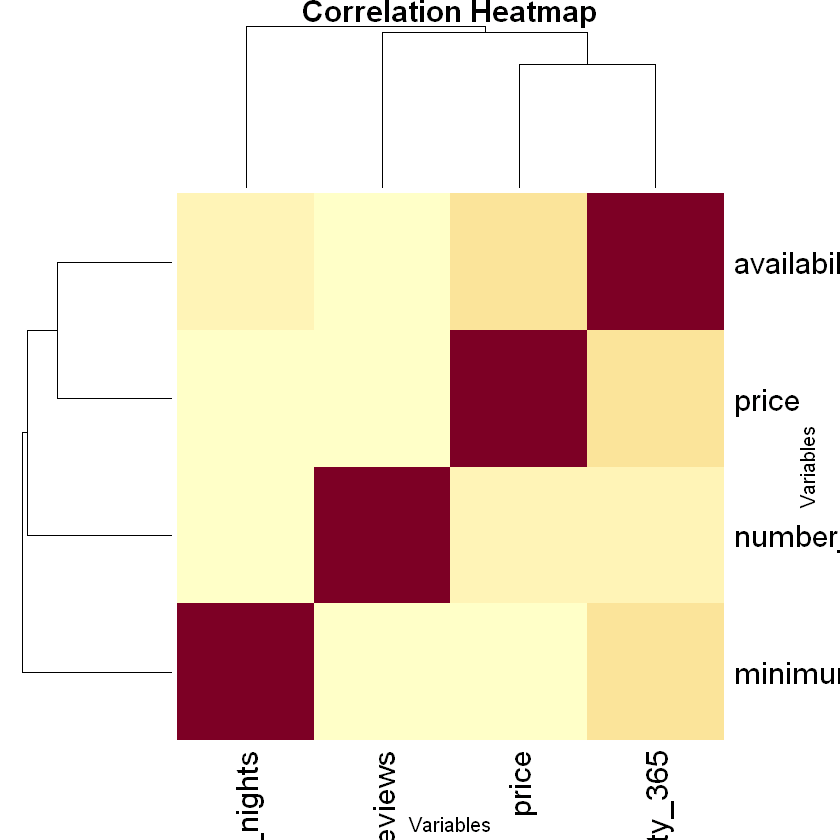

In [7]:
#Libraries required
library(ggplot2)
library(rlang)

#Clean column names (trim, replacements and removals)
names(df_clean) = trimws(names(df_clean))
names(df_clean) = gsub("\\s+", "_", names(df_clean))
names(df_clean) = gsub("\\s+", "_", names(df_clean))
names(df_clean)

#Histogram of listing number of reviews
ggplot(df_clean, aes(x = number_of_reviews)) +
    geom_histogram(binwidth = 10, fill = "skyblue", color = "black") + 
    ggtitle("Histogram of Number of Reviews") + 
    xlab("Number of Reviews") + 
    ylab("Count") + 
    theme_minimal()

#Bar char of minimum nights
ggplot(df_clean, aes(x = factor(minimum_nights))) + 
    geom_bar(fill = "steelblue") + 
    ggtitle("Bar Chart of Minimum Nights") + 
    xlab("Minimum NIghts") +
    ylab("Count") +
    theme_minimal()

#Scatter plot of availability_365
ggplot(df_clean, aes(x = availability_365, y = price)) + 
    geom_point(color = "purple") +
    ggtitle("Availability vs Price") +
    xlab("Number of Reviews") +
    ylab("Price") +
    theme_minimal()

#Correlation heatmap for all numeric values
selected_cols = df_clean[, c("price", "minimum_nights", "number_of_reviews", "availability_365")]
corr_matrix = cor(selected_cols)

heatmap(corr_matrix,
        main = "Correlation Heatmap",
        xlab = "Variables",
        ylab = "Variables")